**0 — Colab: install required packages**

0- This cell installs all the required Python libraries for the project: pandas, numpy, openpyxl for data handling, matplotlib and seaborn for visualization, scikit-learn and joblib for machine learning and saving models, and flask, flask-cors, pyngrok for deploying the model as a web app and making it accessible online. It sets up the environment for data analysis, model building, and deployment.

In [1]:
# Colab cell 0
!pip install -q scikit-learn pandas numpy matplotlib seaborn flask joblib pyngrok flask-cors openpyxl


**1 — Load the dataset (UCI or upload)**

1- This cell loads the Concrete Compressive Strength dataset (from UCI or manual upload), renames the columns to readable names, and displays the dataset’s size and first few records.

In [2]:
# Colab cell 1
import pandas as pd
import io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"

try:
    df = pd.read_excel(url)
    print("Downloaded dataset from UCI.")
except Exception as e:
    print("Automatic download failed. Please upload the dataset file (Concrete_Data.xls or .csv).")
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    if fname.endswith((".xls", ".xlsx")):
        df = pd.read_excel(io.BytesIO(uploaded[fname]))
    else:
        df = pd.read_csv(io.BytesIO(uploaded[fname]))

# Rename columns to friendly names (UCI dataset has these 9 columns)
df.columns = [
    "cement",
    "blast_furnace_slag",
    "fly_ash",
    "water",
    "superplasticizer",
    "coarse_aggregate",
    "fine_aggregate",
    "age",
    "compressive_strength"
]

print("Shape:", df.shape)
df.head()


Downloaded dataset from UCI.
Shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


**2 — Quick EDA and visualization**

2- This cell gives dataset details (info and statistics) and shows a correlation heatmap to visualize relationships between features and compressive strength.



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cement                1030 non-null   float64
 1   blast_furnace_slag    1030 non-null   float64
 2   fly_ash               1030 non-null   float64
 3   water                 1030 non-null   float64
 4   superplasticizer      1030 non-null   float64
 5   coarse_aggregate      1030 non-null   float64
 6   fine_aggregate        1030 non-null   float64
 7   age                   1030 non-null   int64  
 8   compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
None

Describe:


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


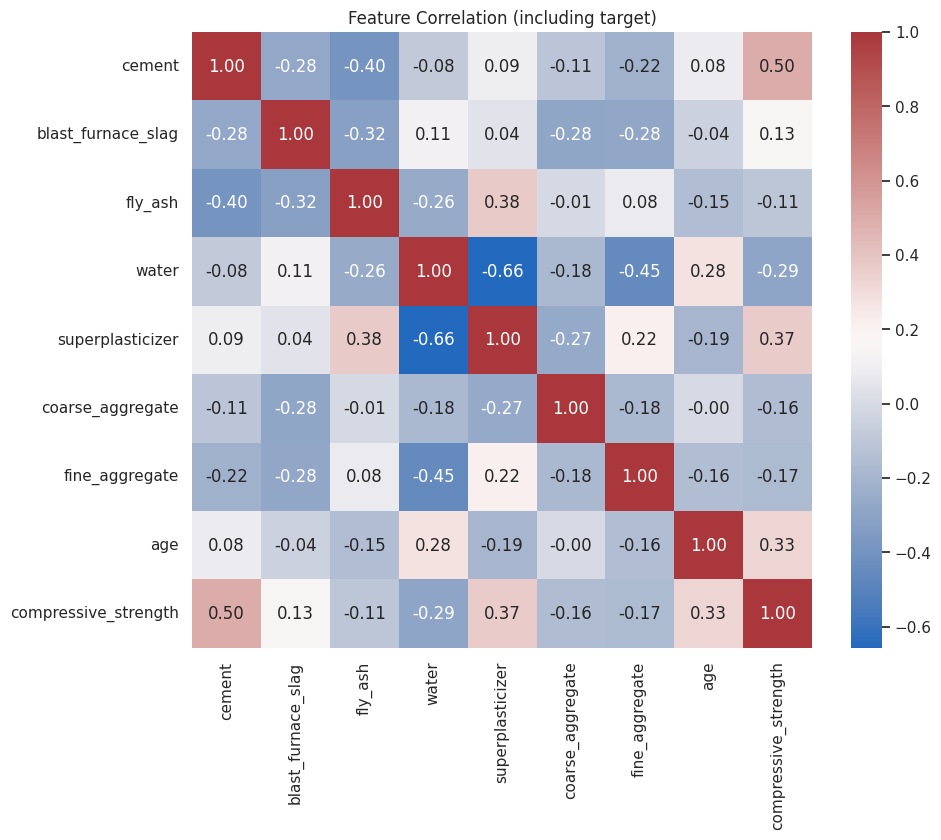

In [3]:
# Colab cell 2
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

print("Info:")
print(df.info())
print("\nDescribe:")
display(df.describe())

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="vlag")
plt.title("Feature Correlation (including target)")
plt.show()


**3 — Train/test split, scaling, model training & evaluation**


We create pipelines for LinearRegression, DecisionTreeRegressor, and RandomForestRegressor and produce a small summary.

3- This cell trains Linear Regression, Decision Tree, and optimized Random Forest models on the dataset and shows a summary comparison of their performance.


In [4]:
# Colab cell 3
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Features / target
X = df.drop(columns=["compressive_strength"])
y = df["compressive_strength"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

def eval_model(pipe, name):
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    return {
        "model": name,
        "MSE": mean_squared_error(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }

# Linear
pipe_lr = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
res_lr = eval_model(pipe_lr, "LinearRegression")

# Decision Tree
pipe_dt = Pipeline([("scaler", StandardScaler()), ("model", DecisionTreeRegressor(random_state=42))])
res_dt = eval_model(pipe_dt, "DecisionTree")

# Random Forest with a small grid search to get a good model
pipe_rf = Pipeline([("scaler", StandardScaler()), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [None, 10, 20]
}
gs = GridSearchCV(pipe_rf, param_grid, cv=3, scoring="r2", n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)
best_rf = gs.best_estimator_
res_rf = {
    "model": "RandomForest (best)",
    "MSE": mean_squared_error(y_test, best_rf.predict(X_test)),
    "MAE": mean_absolute_error(y_test, best_rf.predict(X_test)),
    "R2": r2_score(y_test, best_rf.predict(X_test)),
    "best_params": gs.best_params_
}

# Summary
results = [res_lr, res_dt, res_rf]
results_df = pd.DataFrame(results).set_index("model")
display(results_df)


,MSE,MAE,R2,best_params
model,,,,
LinearRegression,95.975484,7.745393,0.627542,NaN
DecisionTree,53.673240,4.591265,0.791707,NaN
RandomForest (best),30.310923,3.755472,0.882370,"{'model__max_depth': 20, 'model__n_estimators'..."


**4 — Save the best model pipeline + feature order**

We’ll save the chosen pipeline (the Random Forest best_rf from the grid search above if it performed best). This saves the scaler inside the pipeline too.


In [5]:
# Colab cell 4
import joblib, json, os

# Choose best model automatically (highest R2 in results_df)
best_model_name = results_df["R2"].astype(float).idxmax()
print("Best model according to R2:", best_model_name)

# Map names to pipeline objects we trained
model_map = {
    "LinearRegression": pipe_lr,
    "DecisionTree": pipe_dt,
    "RandomForest (best)": best_rf
}
best_pipeline = model_map[best_model_name]

# Save pipeline and feature order
model_path = "concrete_strength_model.pkl"
joblib.dump(best_pipeline, model_path)
print("Saved model to", model_path)

features_path = "features_order.json"
features = list(X.columns)
with open(features_path, "w") as f:
    json.dump(features, f)
print("Saved features order to", features_path)

# Optional: Download files to local machine (Colab UI) or save to Drive if needed


Best model according to R2: RandomForest (best)
Saved model to concrete_strength_model.pkl
Saved features order to features_order.json


**5 — Flask API + minimal web UI (write app file)**


This cell writes a single-file Flask app (app.py) that:

Loads the saved model and features order.

Exposes / (simple HTML page with form).

Exposes /predict (POST JSON) returning predicted strength.

Run the cell to create app.py.


5- This cell creates a Flask web app with a user-friendly interface to input concrete mix data and get compressive strength predictions from the trained model.


In [7]:
  # Colab cell -> Overwrite app.py with a nicer UI (without MSE/MAE/R²)
  %%bash
  cat > app.py <<'PY'
  from flask import Flask, request, jsonify, render_template_string
  import joblib, json, numpy as np, os
  from flask_cors import CORS

  app = Flask(__name__)
  CORS(app)

  # Load model and feature order
  MODEL_PATH = "concrete_strength_model.pkl"
  FEATURES_PATH = "features_order.json"

  if not os.path.exists(MODEL_PATH) or not os.path.exists(FEATURES_PATH):
      raise FileNotFoundError("Model or features file not found. Run training cells first.")

  model = joblib.load(MODEL_PATH)
  with open(FEATURES_PATH, "r") as f:
      FEATURES = json.load(f)

  INDEX_HTML = """
  <!doctype html>
  <html lang="en">
  <head>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width,initial-scale=1" />
    <title>Concrete Strength Predictor</title>

    <!-- Google Font -->
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap" rel="stylesheet">

    <style>
      :root{
        --bg1: #0f172a;
        --bg2: #0b1220;
        --card: #0b1228;
        --accent: linear-gradient(135deg,#06b6d4 0%, #7c3aed 100%);
        --glass: rgba(255,255,255,0.04);
        --muted: rgba(255,255,255,0.65);
        --radius: 14px;
      }

      *{box-sizing:border-box;font-family:Inter,system-ui,-apple-system,Segoe UI,Roboto,"Helvetica Neue",Arial;}
      body{
        margin:0;
        min-height:100vh;
        background: radial-gradient(1200px 600px at 10% 10%, rgba(124,58,237,0.12), transparent 6%),
                    radial-gradient(900px 500px at 90% 90%, rgba(6,182,212,0.08), transparent 6%),
                    linear-gradient(180deg,var(--bg1),var(--bg2));
        color:#e6eef8;
        display:flex;
        align-items:center;
        justify-content:center;
        padding:28px;
      }

      .container{
        width:100%;
        max-width:1000px;
        display:grid;
        grid-template-columns: 1fr 420px;
        gap:28px;
      }

      .card{
        background: linear-gradient(180deg, rgba(255,255,255,0.02), rgba(255,255,255,0.01));
        border-radius: var(--radius);
        padding:24px;
        box-shadow: 0 8px 30px rgba(2,6,23,0.6);
        border: 1px solid rgba(255,255,255,0.03);
      }

      .title{font-size:20px;font-weight:600;margin-bottom:6px;}
      .subtitle{color:var(--muted);font-size:13px;margin-bottom:18px;}

      form{display:grid;grid-template-columns:repeat(2, 1fr);gap:12px;}
      label{display:block;font-size:12px;color:var(--muted);margin-bottom:6px;font-weight:600;}
      input[type=number]{background: rgba(255,255,255,0.02);border: 1px solid rgba(255,255,255,0.04);
        padding:10px 12px;border-radius:10px;color:#e6eef8;font-size:14px;}

      .full {grid-column: 1 / -1;}

      .controls{margin-top:12px;display:flex;gap:12px;}
      button.primary{background: var(--accent);border:none;color:white;padding:10px 16px;
        border-radius:10px;font-weight:700;cursor:pointer;}
      button.ghost{background: transparent;border: 1px solid rgba(255,255,255,0.06);color:var(--muted);
        padding:10px 14px;border-radius:10px;cursor:pointer;}

      .result-card{text-align:center;padding:18px;border-radius:12px;}
      .result-value{font-size:28px;font-weight:800;margin-top:6px;color:#fff;}
      .result-sub{font-size:12px;color:var(--muted);margin-top:6px;}
    </style>
  </head>
  <body>
    <div class="container">
      <div class="card">
        <div class="title">Concrete Compressive Strength Predictor</div>
        <div class="subtitle">Predict compressive strength (MPa) from concrete mix components and age. Units: kg/m³ except age in days.</div>

        <form id="predict-form" autocomplete="off">
          {% for feat in features %}
            <div class="field">
              <label for="{{feat}}">{{feat.replace('_',' ').title()}}</label>
              <input type="number" step="any" id="{{feat}}" name="{{feat}}" required />
            </div>
          {% endfor %}
          <div class="full controls">
            <button class="primary" type="submit">Predict Strength</button>
            <button class="ghost" type="button" id="fill-sample">Fill Example</button>
          </div>
        </form>
      </div>

      <div class="card right">
        <div class="result-card" id="result-card">
          <div style="font-size:13px;color:var(--muted)">Predicted compressive strength</div>
          <div class="result-value" id="result-value">—</div>
          <div class="result-sub" id="result-sub">Enter inputs and press <strong>Predict Strength</strong></div>
        </div>
      </div>
    </div>

  <script>
  document.getElementById('predict-form').onsubmit = async function(e){
    e.preventDefault();
    const data = {};
    {% for feat in features %}
      data["{{feat}}"] = parseFloat(document.getElementById("{{feat}}").value) || 0;
    {% endfor %}

    const resultVal = document.getElementById('result-value');
    const resultSub = document.getElementById('result-sub');

    resultVal.textContent = "Predicting...";
    resultSub.textContent = "Contacting server...";

    try {
      const resp = await fetch('/predict', {
        method: 'POST',
        headers: {'Content-Type': 'application/json'},
        body: JSON.stringify(data)
      });
      const ans = await resp.json();

      if (resp.ok) {
        const pred = parseFloat(ans.predicted_strength_mpa).toFixed(3);
        resultVal.textContent = pred + " MPa";
        resultSub.textContent = "Prediction complete";
      } else {
        resultVal.textContent = "Error";
        resultSub.textContent = ans.error || JSON.stringify(ans);
      }
    } catch (err) {
      resultVal.textContent = "Request failed";
      resultSub.textContent = err.toString();
    }
  };

  document.getElementById('fill-sample').onclick = function(){
    const example = {
      {% for feat in features %}
        "{{feat}}": {{"540.0" if feat=='cement' else ("0.0" if feat in ['blast_furnace_slag','fly_ash'] else ("162.0" if feat=='water' else ("2.5" if feat=='superplasticizer' else ("1040.0" if feat=='coarse_aggregate' else ("676.0" if feat=='fine_aggregate' else ("28" if feat=='age' else "0")))))) }}{% if not loop.last %},{% endif %}
      {% endfor %}
    };
    for (const k in example) {
      const el = document.getElementById(k);
      if (el) el.value = example[k];
    }
  };
  </script>
  </body>
  </html>
  """

  from jinja2 import Template
  index_html_final = Template(INDEX_HTML).render(features=FEATURES)

  @app.route("/", methods=["GET"])
  def index():
      return index_html_final

  @app.route("/predict", methods=["POST"])
  def predict():
      data = request.get_json(force=True)
      try:
          feat_list = [float(data.get(k, 0)) for k in FEATURES]
      except Exception as e:
          return jsonify({"error": "Invalid input: " + str(e)}), 400

      arr = np.array(feat_list).reshape(1, -1)
      pred = model.predict(arr)[0]
      return jsonify({"predicted_strength_mpa": float(pred)})

  if __name__ == "__main__":
      app.run(host="0.0.0.0", port=5000)
  PY
  echo "Wrote app.py (metrics removed)"



Wrote app.py (metrics removed)


**6 — Expose the Flask app with ngrok and run it in Colab**

Use pyngrok to create a public URL so you can open the UI in your browser. Run this cell after the app.py file is created and saved model exists.

6- This cell installs pyngrok and sets up your ngrok authtoken, enabling the Flask app to be accessed via a public URL from Colab.

In [8]:
# Colab cell (run before Cell 6)

# Install pyngrok if not already installed
!pip install -q pyngrok

# Configure ngrok with your authtoken
!ngrok config add-authtoken 32PgtSRqSI9AsCQe3BTHH5TsQTR_7DQhtjSvpJegfiKMyrDJ3


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [9]:
# This cell starts the Flask app in the background and creates a public ngrok URL so you can access the web interface from anywhere.



# Colab cell 6
# Start ngrok and app in the background
from pyngrok import ngrok
import subprocess, time, os
port = 5000

# Create ngrok tunnel
public_url = ngrok.connect(port).public_url
print(" * Ngrok URL:", public_url)

# Run the Flask app in background
# (we previously wrote app.py)
process = subprocess.Popen(["python", "app.py"], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

print("Flask app started in background (PID {}). Wait a moment and open the Ngrok URL above.".format(process.pid))
time.sleep(2)


 * Ngrok URL: https://88cab372ad56.ngrok-free.app
Flask app started in background (PID 3593). Wait a moment and open the Ngrok URL above.


**7 — Test the API programmatically**


7- This cell sends a test request to the Flask app via ngrok and prints the predicted concrete strength.




In [10]:

import requests
import time

# Wait a little to ensure the server + ngrok tunnel are up
time.sleep(5)

# Fetch the public URL from ngrok’s local API
try:
    ngrok_tunnels = requests.get("http://localhost:4040/api/tunnels").json()
    public_url = ngrok_tunnels["tunnels"][0]["public_url"]
    print("Using public URL:", public_url)
except Exception as e:
    print("❌ Could not get ngrok public URL:", e)
    public_url = None

# If public_url is valid, send the test request
if public_url:
    test_input = {
        "cement": 540.0,
        "blast_furnace_slag": 0.0,
        "fly_ash": 0.0,
        "water": 162.0,
        "superplasticizer": 2.5,
        "coarse_aggregate": 1040.0,
        "fine_aggregate": 676.0,
        "age": 28
    }
    try:
        resp = requests.post(public_url + "/predict", json=test_input, timeout=10)
        print("Status:", resp.status_code)
        # Try parsing JSON, but catch if invalid
        try:
            print("Response JSON:", resp.json())
        except ValueError:
            print("Response not in JSON format. Raw response:")
            print(resp.text)
    except requests.exceptions.RequestException as e:
        print("❌ Request failed:", e)
else:
    print("❌ Skipping test request because public_url is missing.")


Using public URL: https://88cab372ad56.ngrok-free.app
Status: 200
Response JSON: {'predicted_strength_mpa': 72.65008611999998}
